# Dependencies:

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("Running")

Running


# Data Cleaning

In [34]:
users_df = pd.read_excel("archive/users.xlsx")
events_df = pd.read_excel("archive/events.xlsx")

print("--USER DATA--")
display(users_df.head())

print("--EVENT DATA--")
display(events_df.head())

--USER DATA--


,user_id,install_date
0,1,2024-01-07
1,2,2024-01-20
2,3,2024-01-29
3,4,2024-01-15
4,5,2024-01-11


--EVENT DATA--


,user_id,event_date,event_type
0,1,2024-01-07,session_start
1,1,2024-01-08,session_start
2,1,2024-01-09,session_start
3,1,2024-01-10,session_start
4,1,2024-01-11,session_start


In [35]:
users_df.info()
events_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       5000 non-null   int64         
 1   install_date  5000 non-null   datetime64[us]
dtypes: datetime64[us](1), int64(1)
memory usage: 78.3 KB
<class 'pandas.DataFrame'>
RangeIndex: 27291 entries, 0 to 27290
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     27291 non-null  int64         
 1   event_date  27291 non-null  datetime64[us]
 2   event_type  27291 non-null  str           
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 639.8 KB


In [36]:
user_activity = events_df.groupby("user_id").agg(
    total_sessions = ("event_type","count"),
    last_session = ("event_date","max")
).reset_index()

df = pd.merge(user_activity,users_df,on="user_id",how="left")
dataset_max_date = events_df["event_date"].max()

df["days_active"] = (df["last_session"] - df["install_date"]).dt.days
df["days_inactive"] = (dataset_max_date - df["last_session"]).dt.days
df["account_age"] = (dataset_max_date - df["install_date"]).dt.days

df["churn"] = (df["days_inactive"]>7).astype(int)

print("--MASTER DATASET--")
df.head()

--MASTER DATASET--


,user_id,total_sessions,last_session,install_date,days_active,days_inactive,account_age,churn
0,1,6,2024-01-12,2024-01-07,5,53,58,1
1,2,4,2024-01-23,2024-01-20,3,42,45,1
2,3,11,2024-02-08,2024-01-29,10,26,36,1
3,4,2,2024-01-16,2024-01-15,1,49,50,1
4,5,6,2024-01-16,2024-01-11,5,49,54,1


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         5000 non-null   int64         
 1   total_sessions  5000 non-null   int64         
 2   last_session    5000 non-null   datetime64[us]
 3   install_date    5000 non-null   datetime64[us]
 4   days_active     5000 non-null   int64         
 5   days_inactive   5000 non-null   int64         
 6   account_age     5000 non-null   int64         
 7   churn           5000 non-null   int64         
dtypes: datetime64[us](2), int64(6)
memory usage: 312.6 KB


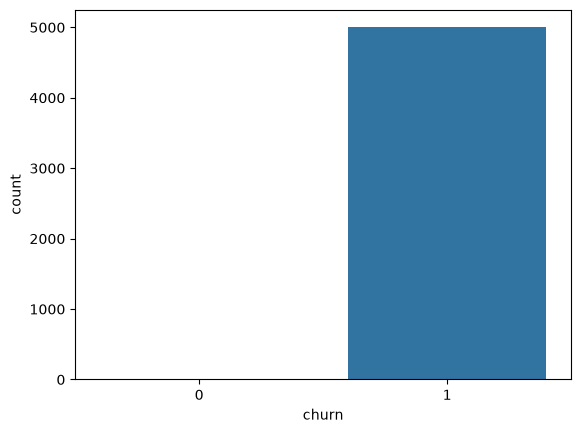

In [38]:
sns.countplot(x="churn", data=df)
plt.show()

In [39]:
df["days_inactive"].describe()

count    5000.000000
mean       44.960400
std        10.070547
min         0.000000
25%        37.000000
50%        45.000000
75%        53.000000
max        64.000000
Name: days_inactive, dtype: float64

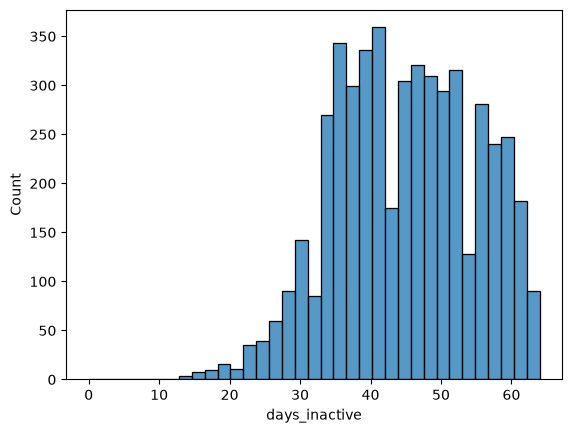

In [40]:
sns.histplot(data=df['days_inactive'])
plt.show()

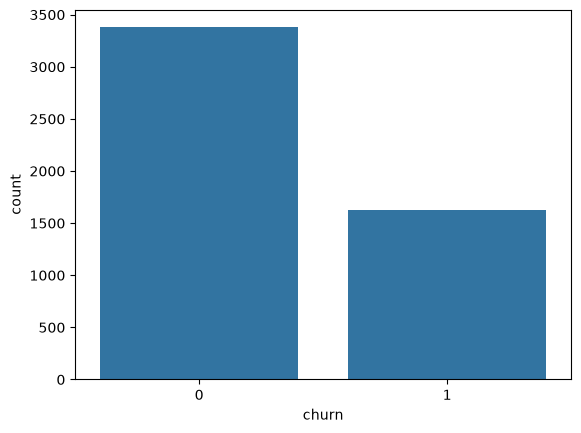

In [41]:
df['churn'] = (df["days_inactive"]>50).astype(int)
sns.countplot(x="churn",data=df)
plt.show()

In [42]:
cm = df.corr(numeric_only=True)
print(cm)

                 user_id  total_sessions  days_active  days_inactive  \
user_id         1.000000       -0.006636    -0.006636       0.013721   
total_sessions -0.006636        1.000000     1.000000      -0.493259   
days_active    -0.006636        1.000000     1.000000      -0.493259   
days_inactive   0.013721       -0.493259    -0.493259       1.000000   
account_age     0.012027       -0.002586    -0.002586       0.871155   
churn           0.007362       -0.274958    -0.274958       0.788802   

                account_age     churn  
user_id            0.012027  0.007362  
total_sessions    -0.002586 -0.274958  
days_active       -0.002586 -0.274958  
days_inactive      0.871155  0.788802  
account_age        1.000000  0.751588  
churn              0.751588  1.000000  


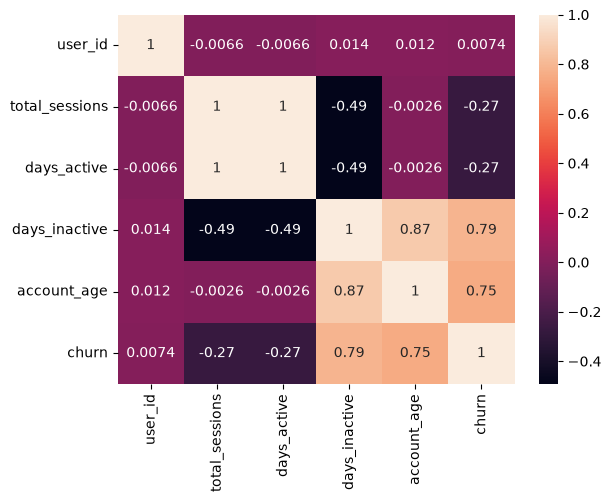

In [43]:
sns.heatmap(cm,annot=True)
plt.show()

In [44]:
master_df = df
df = df.drop(["account_age","days_inactive","user_id","days_active","last_session","install_date"],axis="columns")
df.head()

# "account_age" was later dropped

,total_sessions,churn
0,6,1
1,4,0
2,11,0
3,2,0
4,6,0


In [45]:
y = df["churn"]
df = df.drop('churn',axis='columns')
X = df

## Experiment 1: Logistic Rgression

In [46]:
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled[:3])

[[-0.69955045]
 [-0.69955045]
 [ 0.12007515]]


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lor = LogisticRegression(max_iter=10000, random_state=42)
lor.fit(X_train_scaled, y_train)

acc = accuracy_score(y_test, lor.predict(X_test_scaled))*100
print(f"Logistic Regression model accuracy: {acc:.2f}%")

Logistic Regression model accuracy: 67.00%


In [48]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = lor.predict(X_test_scaled)

print("--CLASSIFICATION REPORT--")
print(classification_report(y_test, y_pred))

print("\n--CONFUSION MATRIX--")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print("-" * 30)

print(f"True Negatives  (Correctly predicted Stay) : {cm[0][0]}")
print(f"False Positives (Falsely predicted Churn)  : {cm[0][1]}")
print(f"False Negatives (Falsely predicted Stay)   : {cm[1][0]}")
print(f"True Positives  (Correctly predicted Churn): {cm[1][1]}")

--CLASSIFICATION REPORT--
              precision    recall  f1-score   support

           0       0.67      1.00      0.80       670
           1       0.00      0.00      0.00       330

    accuracy                           0.67      1000
   macro avg       0.34      0.50      0.40      1000
weighted avg       0.45      0.67      0.54      1000


--CONFUSION MATRIX--
[[670   0]
 [330   0]]
------------------------------
True Negatives  (Correctly predicted Stay) : 670
False Positives (Falsely predicted Churn)  : 0
False Negatives (Falsely predicted Stay)   : 330
True Positives  (Correctly predicted Churn): 0


/home/lenovo/Desktop/player-churn-prediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/lenovo/Desktop/player-churn-prediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/lenovo/Desktop/player-churn-prediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [49]:
lor_A = LogisticRegression(class_weight='balanced', random_state=42, max_iter=10000)
lor_A.fit(X_train_scaled, y_train)

y_pred = lor_A.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

acc_A = accuracy_score(y_test, lor_A.predict(X_test_scaled))*100
print(f"Logistic Regression model accuracy: {acc_A:.2f}%")

[[352 318]
 [ 80 250]]
              precision    recall  f1-score   support

           0       0.81      0.53      0.64       670
           1       0.44      0.76      0.56       330

    accuracy                           0.60      1000
   macro avg       0.63      0.64      0.60      1000
weighted avg       0.69      0.60      0.61      1000

Logistic Regression model accuracy: 60.20%


Engineered a new feature "sessions_per_day" to improve the accuracy by providing more data to the model.

In [50]:
df = master_df
df['sessions_per_day'] = df['total_sessions'] / df['account_age']
df.head()

,user_id,total_sessions,last_session,install_date,days_active,days_inactive,account_age,churn,sessions_per_day
0,1,6,2024-01-12,2024-01-07,5,53,58,1,0.103448
1,2,4,2024-01-23,2024-01-20,3,42,45,0,0.088889
2,3,11,2024-02-08,2024-01-29,10,26,36,0,0.305556
3,4,2,2024-01-16,2024-01-15,1,49,50,0,0.040000
4,5,6,2024-01-16,2024-01-11,5,49,54,0,0.111111


In [51]:
df = df.drop(columns=['last_session','install_date','days_active','days_inactive','account_age'])
df.head()

,user_id,total_sessions,churn,sessions_per_day
0,1,6,1,0.103448
1,2,4,0,0.088889
2,3,11,0,0.305556
3,4,2,0,0.040000
4,5,6,0,0.111111


In [52]:
y = df['churn']
df = df.drop("churn",axis='columns')
X = df

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [54]:
lor_A = LogisticRegression(class_weight='balanced', random_state=42, max_iter=10000)
lor_A.fit(X_train_scaled, y_train)

y_pred = lor_A.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

acc_A = accuracy_score(y_test, lor_A.predict(X_test_scaled))*100
print(f"Logistic Regression model accuracy: {acc_A:.2f}%")

[[557 113]
 [  6 324]]
              precision    recall  f1-score   support

           0       0.99      0.83      0.90       670
           1       0.74      0.98      0.84       330

    accuracy                           0.88      1000
   macro avg       0.87      0.91      0.87      1000
weighted avg       0.91      0.88      0.88      1000

Logistic Regression model accuracy: 88.10%


## Experiment 2: Decision Tree

In [55]:
from sklearn.tree import DecisionTreeClassifier

df = master_df
df = df.drop(columns=['last_session','install_date','days_active','days_inactive','account_age'])
df.head()
y = df['churn']
df = df.drop("churn",axis='columns')
X = df

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [56]:
dce = DecisionTreeClassifier(random_state=42)
dce.fit(X_train, y_train)

y_pred = dce.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, dce.predict(X_test)) * 100
print(f"Decision Tree model accuracy: {acc:.2f}%")

[[668   2]
 [  0 330]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       670
           1       0.99      1.00      1.00       330

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

Decision Tree model accuracy: 99.80%


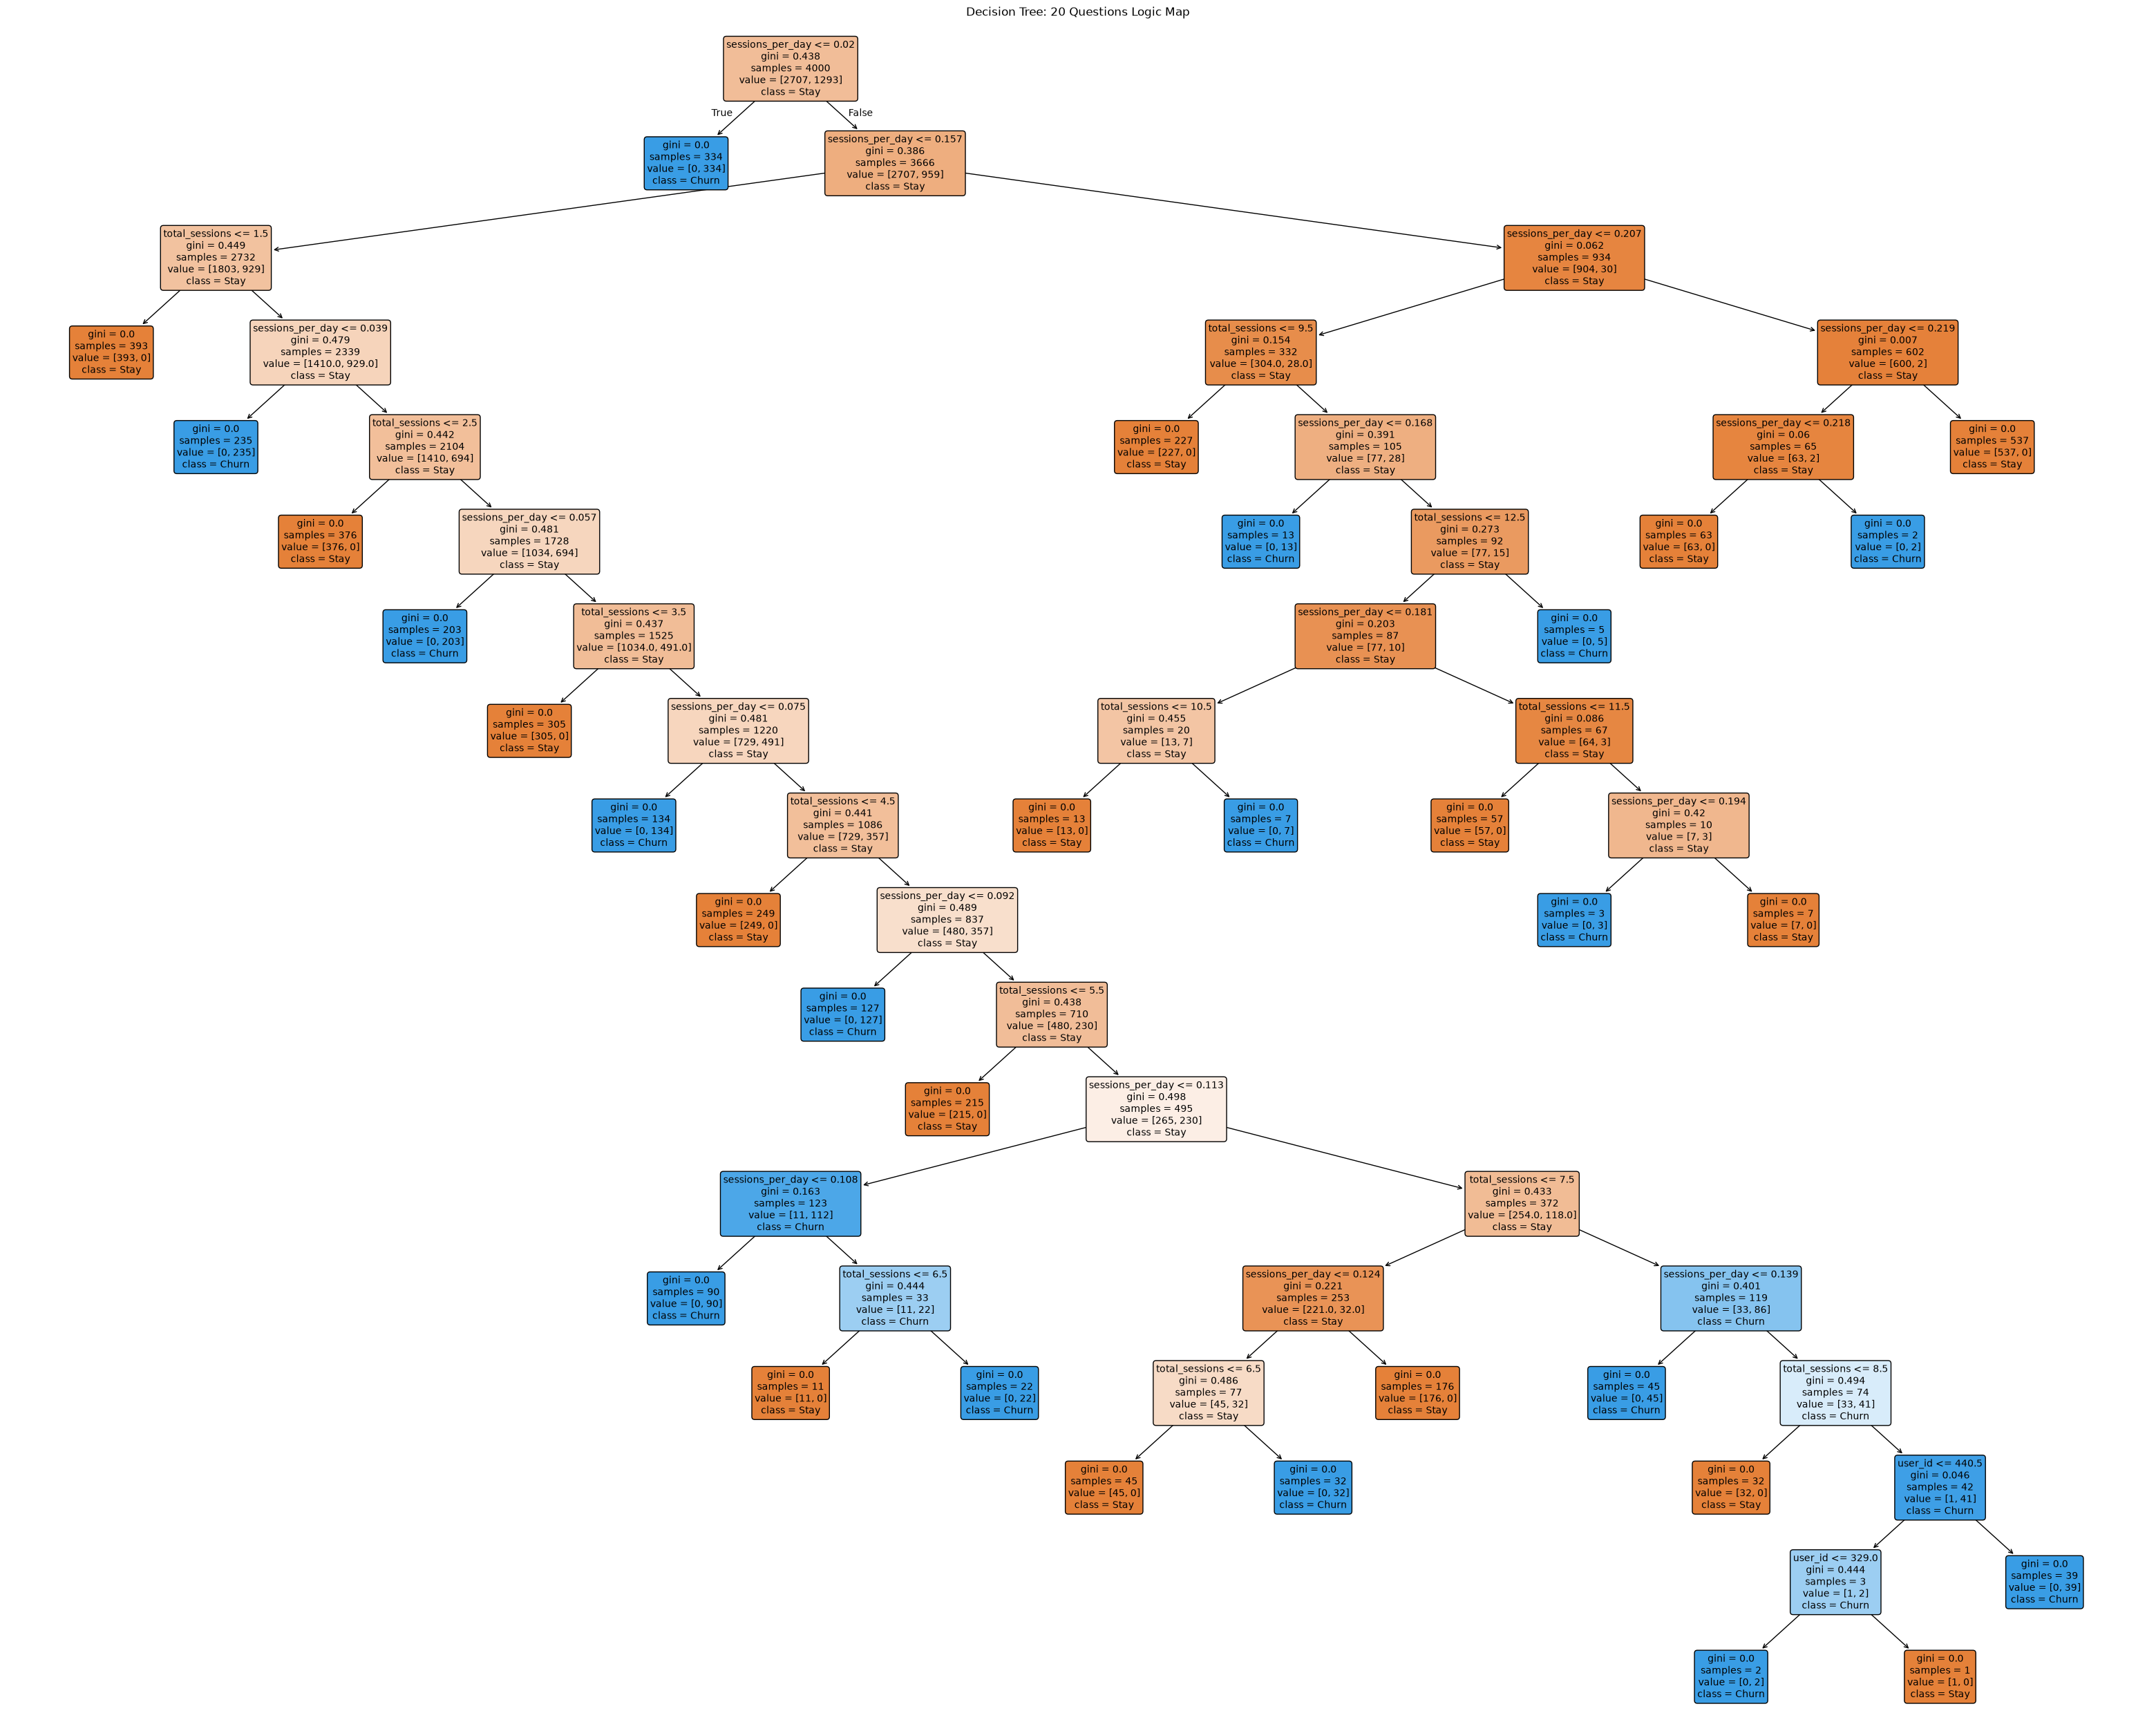

In [57]:
from sklearn.tree import plot_tree

plt.figure(figsize=(40, 32))
plot_tree(dce, 
          feature_names=X.columns, 
          class_names=['Stay', 'Churn'], 
          filled=True, 
          rounded=True, 
          fontsize=10)

plt.title("Decision Tree: 20 Questions Logic Map")
plt.show()

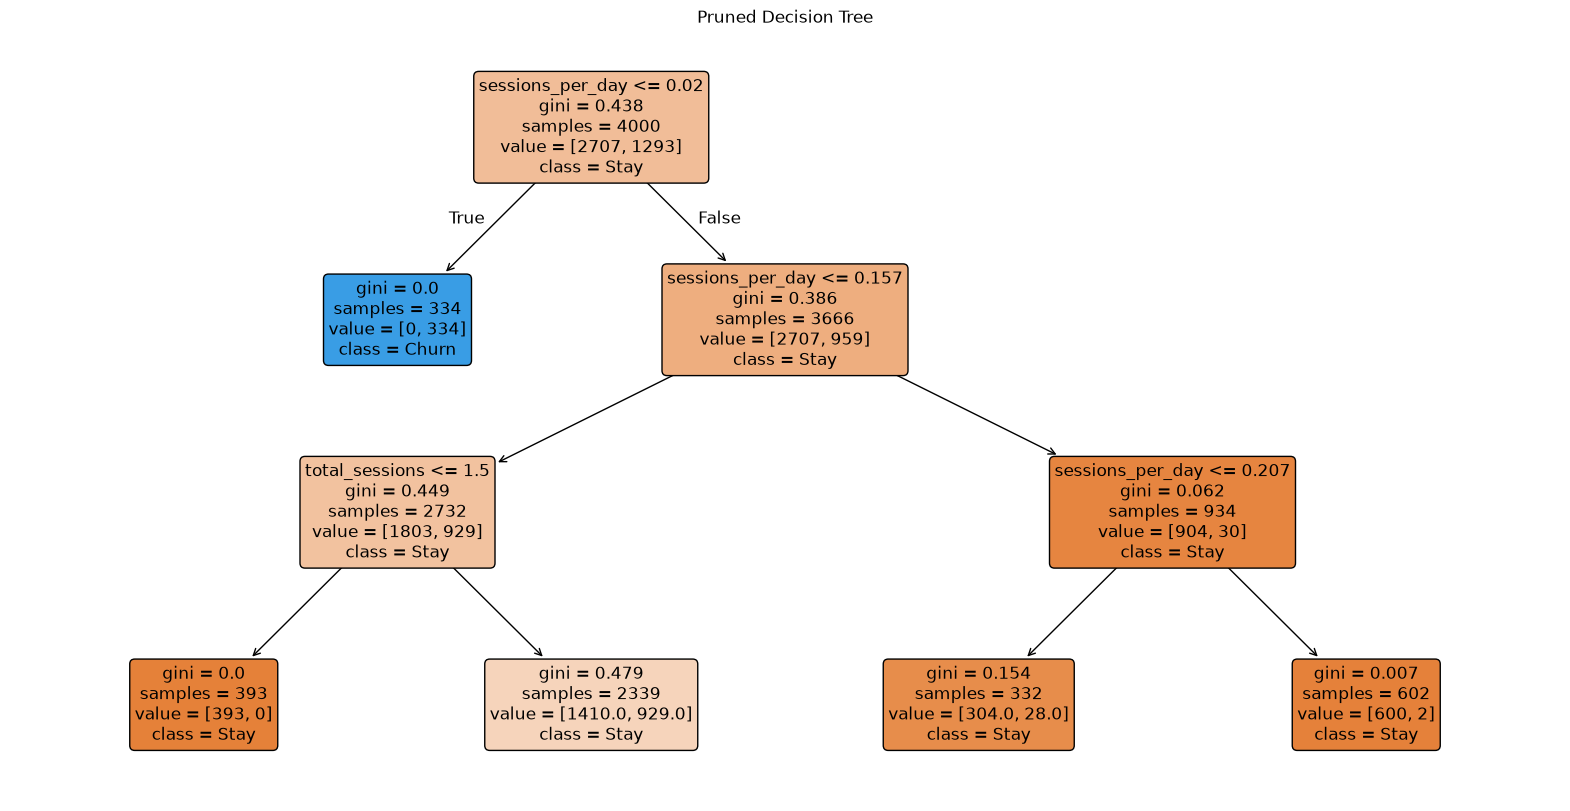

In [58]:
dce_A = DecisionTreeClassifier(max_depth=3, random_state=42)
dce_A.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(dce_A, 
          feature_names=X.columns, 
          class_names=['Stay', 'Churn'], 
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.title("Pruned Decision Tree")
plt.show()

In [59]:
y_pred = dce_A.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, dce_A.predict(X_test)) * 100
print(f"Decision Tree model accuracy: {acc:.2f}%")

[[670   0]
 [244  86]]
              precision    recall  f1-score   support

           0       0.73      1.00      0.85       670
           1       1.00      0.26      0.41       330

    accuracy                           0.76      1000
   macro avg       0.87      0.63      0.63      1000
weighted avg       0.82      0.76      0.70      1000

Decision Tree model accuracy: 75.60%


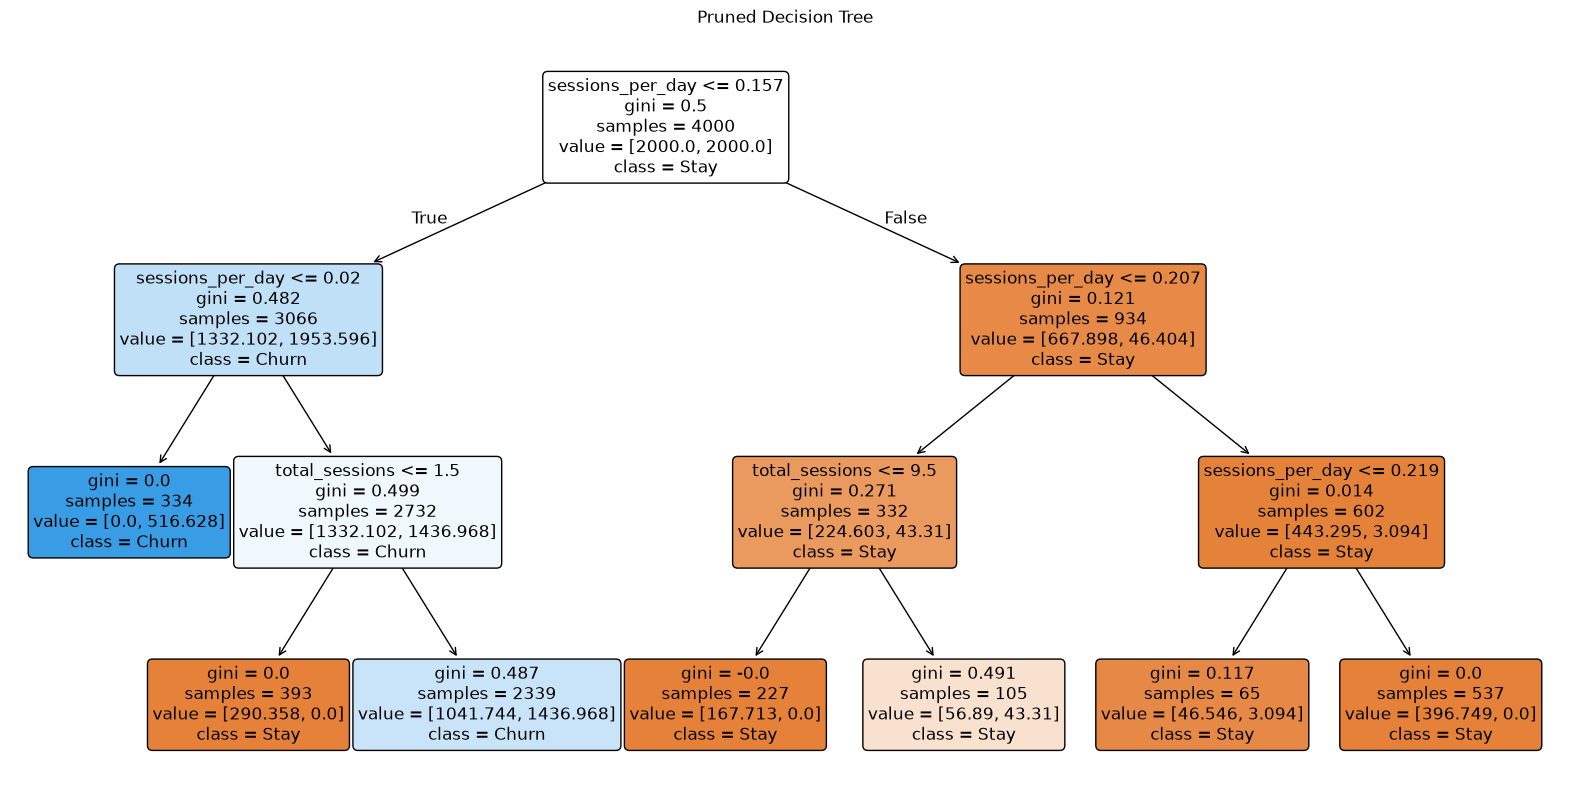

[[343 327]
 [  8 322]]
              precision    recall  f1-score   support

           0       0.98      0.51      0.67       670
           1       0.50      0.98      0.66       330

    accuracy                           0.67      1000
   macro avg       0.74      0.74      0.66      1000
weighted avg       0.82      0.67      0.67      1000

Decision Tree model accuracy: 66.50%


In [60]:
dce_B = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
dce_B.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(dce_B, 
          feature_names=X.columns, 
          class_names=['Stay', 'Churn'], 
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.title("Pruned Decision Tree")
plt.show()

y_pred = dce_B.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, dce_B.predict(X_test)) * 100
print(f"Decision Tree model accuracy: {acc:.2f}%")

## Experiment 3: Random Forest:

In [61]:
df = master_df
df = df.drop(columns=['last_session','install_date','days_active','days_inactive','account_age','user_id'])
df.head()
y = df['churn']
df = df.drop("churn",axis='columns')
X = df

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    bootstrap=True,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, y_pred) * 100
print(f"Accuracy: {acc:.2f}")


[[670   0]
 [  0 330]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       670
           1       1.00      1.00      1.00       330

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

Accuracy: 100.00


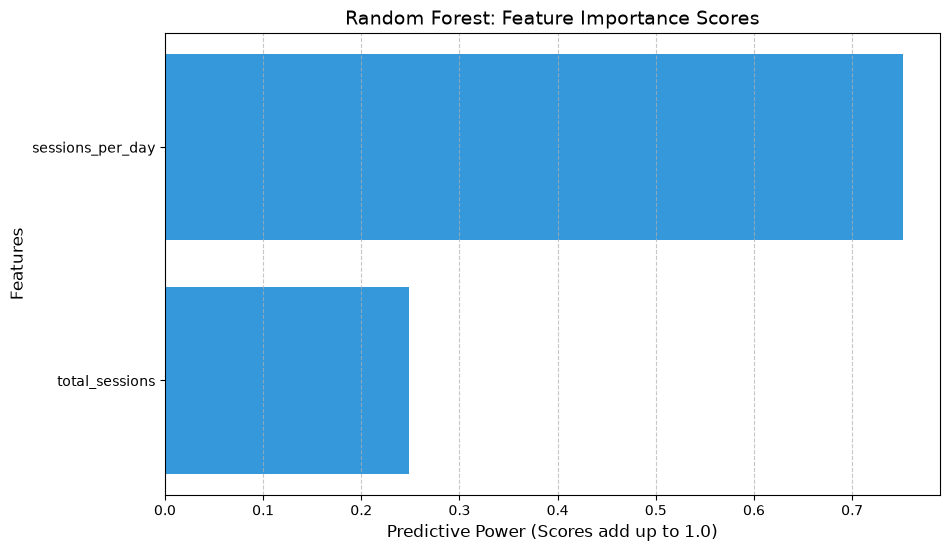

In [63]:
importances = rf.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#3498db')
plt.title("Random Forest: Feature Importance Scores", fontsize=14)
plt.xlabel("Predictive Power (Scores add up to 1.0)", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()